# SINASC 2014–2024 — descritiva temporal (07)

**Referência certificada:** SINASC 2024 (notebooks 01–05), congelada.
**Extensão em desenvolvimento:** multianual. Nada neste notebook é inferência causal.

| Janela | Anos | Contrato |
|---|---|---|
| **Principal** | 2014–2024 | v1.1 = v1 + harmonização H1 (identificador) |
| **Sensibilidade obrigatória** | 2018–2024 | v1 estrito, sem H1 |

## 1. Objetivo

Mostrar como a população, o tratamento, o desfecho e as covariáveis congeladas se comportam de 2014 a 2024 **antes** de qualquer nova inferência.

Perguntas:

1. os padrões observados em 2024 persistem ao longo de 2014–2023?
2. 2024 é estruturalmente semelhante aos anos anteriores ou tem alguma particularidade importante?

Mais anos aumentam a **evidência sobre estabilidade temporal**; não aumentam, por si, a **validade causal**. Confundimento residual, seleção entre nascidos vivos e erro de registro continuam presentes em cada ano.

Fora do escopo: escore de propensão, AIPW, CATE e análise empilhada (*pooled*).

In [1]:
from pathlib import Path
import sys, json, time
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Image
raiz = next(p for p in (Path.cwd(), Path.cwd().parent) if (p / 'src').exists()).resolve()
sys.path.insert(0, str(raiz))
assert Path(sys.executable).resolve() == (raiz / '.venv/Scripts/python.exe').resolve(), 'Use a .venv do projeto'
from src import temporal as tp
from src.sinasc import calcular_sha256
from src.visualizacao import configurar_plotly, aplicar_tema_ipt
configurar_plotly()
pd.set_option('display.max_columns', 30); pd.set_option('display.width', 220)

ANOS = list(range(2014, 2025))
ANOS_NOVOS = [a for a in ANOS if a != tp.ANO_BASELINE]
pasta_tabelas = raiz / 'outputs/temporal/tabelas'; pasta_tabelas.mkdir(parents=True, exist_ok=True)
# Figuras seguem a convenção do projeto: outputs/figures/ (local, fora do Git); o notebook as incorpora.
pasta_figuras = raiz / 'outputs/figures'; pasta_figuras.mkdir(parents=True, exist_ok=True)
UF = {'11': 'RO', '12': 'AC', '13': 'AM', '14': 'RR', '15': 'PA', '16': 'AP', '17': 'TO', '21': 'MA',
      '22': 'PI', '23': 'CE', '24': 'RN', '25': 'PB', '26': 'PE', '27': 'AL', '28': 'SE', '29': 'BA',
      '31': 'MG', '32': 'ES', '33': 'RJ', '35': 'SP', '41': 'PR', '42': 'SC', '43': 'RS', '50': 'MS',
      '51': 'MT', '52': 'GO', '53': 'DF', 'IGNORADO': 'Ignorada'}
EVENTOS = [(2015, 2016, 'Zika'), (2020, 2021, 'COVID-19')]

def marcar_eventos(fig):
    """Faixas contextuais (Zika, COVID-19); marcadores de leitura, não explicação causal."""
    todos = dict(row='all', col='all') if getattr(fig, '_grid_ref', None) else {}
    for inicio, fim, nome in EVENTOS:
        fig.add_vrect(x0=inicio - 0.5, x1=fim + 0.5, fillcolor='#999999', opacity=0.12, line_width=0,
                      annotation_text=nome, annotation_position='top left', **todos)
    return fig

def mostrar(fig, titulo, nome, altura=560):
    aplicar_tema_ipt(fig, titulo)
    fig.update_layout(width=1100, height=altura, margin=dict(l=100, r=55, t=100, b=90))
    fig.update_xaxes(automargin=True, dtick=1); fig.update_yaxes(automargin=True)
    p = pasta_figuras / f'temporal_{nome}.png'
    fig.write_image(p); display(Image(filename=str(p)))

def salvar(tabela, nome):
    tabela.to_csv(pasta_tabelas / f'{nome}.csv', index=False, float_format='%.6f', lineterminator='\n')
    return tabela
JANELA_PRINCIPAL = list(tp.JANELAS['principal']['anos'])
JANELA_SENSIBILIDADE = list(tp.JANELAS['sensibilidade']['anos'])
print('Contrato v1  :', tp.VERSAO_CRITERIOS_V1)
print('Contrato v1.1:', tp.VERSAO_CRITERIOS_V1_1)
print('Janela principal:', JANELA_PRINCIPAL[0], '–', JANELA_PRINCIPAL[-1], '(v1.1)')
print('Sensibilidade obrigatória:', JANELA_SENSIBILIDADE[0], '–', JANELA_SENSIBILIDADE[-1], '(v1 estrito)')

Contrato v1  : 1 (fixada em 2026-09-29, antes da leitura dos arquivos completos)
Contrato v1.1: 1.1 = v1 + H1 (H1 identificada em 2026-09-29 após a leitura completa; aprovada em revisão humana em 2026-09-30; antes de qualquer estimação causal multianual)
Janela principal: 2014 – 2024 (v1.1)
Sensibilidade obrigatória: 2018 – 2024 (v1 estrito)


## 2. Contrato temporal

- A referência é o SINASC 2024 **certificado**, lido apenas pelos caminhos legados; nenhum arquivo de 2024 é baixado, convertido ou reescrito.
- Cada ano usa **as mesmas regras de 2024**: as views congeladas de `src/amostra.py` (T: `MESPRENAT` 1–3 versus 4–9; Y: `PESO` < 2.500 g com qualidade 500–6.000 g; gestação única) e as mesmas sete covariáveis.
- A chave da camada temporal é `(ano, UF_res, CONTADOR)` em todos os anos (necessária em 2014–2017 pela H1; equivalente a `CONTADOR` em 2018–2024). Nenhuma chave liga registros entre anos; o contrato certificado de 2024 continua usando `CONTADOR`.
- Os nomes das colunas são lidos sem diferenciar caixa; o esquema original de cada ano fica registrado no manifesto.

A célula abaixo confere os hashes certificados de 2024 antes de qualquer leitura.

In [2]:
impressao = tp.impressao_baseline(raiz)
f2 = json.loads((raiz / 'outputs/diagnostics/fase2_aipw.json').read_text(encoding='utf-8'))
assert impressao['parquet_2024'] == f2['provenance']['parquet_sha256']
assert impressao['zip_2024'] == tp._sha256_baseline(raiz)
assert impressao['source_manifest'] == 'c1fdc4277225e1a604c1277d0267100dd9d12957e4f2b71ac25461eb9f470eca'
display(pd.Series(impressao, name='SHA-256 certificado').to_frame())

,SHA-256 certificado
zip_2024,27e55de6359e1b1914301dc1d752d78e9535a7a52cc064...
parquet_2024,a7a1618e555d1417f692b5334b2a0fd01cfee911b3d45c...
source_manifest,c1fdc4277225e1a604c1277d0267100dd9d12957e4f2b7...


## 3. Anos analisados

Fonte oficial de cada ano: recurso "Nascidos Vivos - <ano>" do Portal de Dados Abertos do SUS. Os ZIPs de 2014–2023 foram baixados um ano por vez, com retomada por HTTP Range, verificação de tamanho e CRC, e registrados em `outputs/temporal/manifestos/sinasc_<ano>.json`. Os Parquets usam a mesma conversão textual de 2024. A tabela recalcula os SHA-256 dos arquivos locais e confere com os manifestos.

In [3]:
linhas = []
for ano in ANOS_NOVOS:
    m = tp.ler_manifesto_ano(raiz, ano); c = tp.caminhos_ano(raiz, ano); conv = m['conversao']
    linhas.append({'ano': ano, 'fonte': m['url'], 'zip_mb': m['tamanho_bytes'] / 1e6,
                   'zip_sha256': m['sha256'], 'zip_confere': calcular_sha256(c.zip_bruto) == m['sha256'],
                   'crc_verificado': m['crc_verificado'], 'csv_interno': conv['csv_interno'],
                   'encoding': conv['encoding'], 'separador': conv['separador'], 'n_colunas': conv['n_colunas'],
                   'n_registros': conv['n_registros'], 'parquet_mb': conv['parquet_bytes'] / 1e6,
                   'parquet_sha256': conv['parquet_sha256'],
                   'parquet_confere': calcular_sha256(c.parquet) == conv['parquet_sha256'],
                   'segundos_conversao': conv['segundos_conversao'], 'ultima_modificacao_remota': m['ultima_modificacao_remota']})
c24 = tp.caminhos_ano(raiz, 2024)
linhas.append({'ano': 2024, 'fonte': tp.url_sinasc(2024), 'zip_mb': c24.zip_bruto.stat().st_size / 1e6,
               'zip_sha256': impressao['zip_2024'], 'zip_confere': True, 'crc_verificado': None,
               'csv_interno': 'SINASC_2024.csv', 'encoding': 'utf-8', 'separador': ';', 'n_colunas': 62,
               'n_registros': None, 'parquet_mb': c24.parquet.stat().st_size / 1e6,
               'parquet_sha256': impressao['parquet_2024'], 'parquet_confere': True,
               'segundos_conversao': None, 'ultima_modificacao_remota': 'certificado (source_manifest.json)'})
arquivos = pd.DataFrame(linhas)
assert arquivos.zip_confere.all() and arquivos.parquet_confere.all()
display(arquivos.drop(columns=['fonte']).assign(zip_sha256=lambda d: d.zip_sha256.str[:16] + '…',
                                                  parquet_sha256=lambda d: d.parquet_sha256.str[:16] + '…'))

,ano,zip_mb,zip_sha256,zip_confere,crc_verificado,csv_interno,encoding,separador,n_colunas,n_registros,parquet_mb,parquet_sha256,parquet_confere,segundos_conversao,ultima_modificacao_remota
0,2014,126.839993,892ab530ea218354…,True,True,SINASC_2014.csv,utf-8,;,61,2979259.0,69.465734,b201bf9ecda6f669…,True,71.7,"Tue, 21 Oct 2025 20:09:29 GMT"
1,2015,127.210201,0e35031cccc7a26f…,True,True,SINASC_2015.csv,utf-8,;,61,3017668.0,69.918843,d6f1384db37cd277…,True,72.3,"Tue, 21 Oct 2025 20:09:29 GMT"
2,2016,107.375201,a25e4d65e0ebd91a…,True,True,SINASC_2016.csv,utf-8,;,61,2857800.0,70.972289,483b1036809e49ce…,True,66.1,"Fri, 08 May 2026 17:26:23 GMT"
3,2017,119.200433,6a526a0245e68085…,True,True,SINASC_2017.csv,utf-8,;,61,2923535.0,68.236897,7e28ea30b56d59c6…,True,67.4,"Fri, 08 May 2026 17:26:32 GMT"
4,2018,119.578829,1367ac0d8350e741…,True,True,SINASC_2018.csv,utf-8,;,61,2944932.0,67.945500,cfff334ad6ec45ee…,True,68.8,"Fri, 08 May 2026 17:26:40 GMT"
5,2019,115.471101,4d528a8b6338ac3d…,True,True,SINASC_2019.csv,utf-8,;,61,2849146.0,65.457805,c0ada054bbffb03f…,True,66.6,"Fri, 08 May 2026 17:26:48 GMT"
6,2020,110.956183,d06af4961ab021cf…,True,True,SINASC_2020.csv,utf-8,;,61,2730145.0,63.126678,cb271925a648c696…,True,64.0,"Fri, 08 May 2026 17:26:56 GMT"
7,2021,108.627610,240eb1f03aa9cb5e…,True,True,SINASC_2021.csv,utf-8,;,61,2677101.0,61.983638,fc349f75802c4b69…,True,61.9,"Fri, 08 May 2026 17:40:32 GMT"
8,2022,105.146642,89e6f791a2470588…,True,True,SINASC_2022.csv,utf-8,;,61,2561922.0,58.557616,a357f6785672e19f…,True,60.3,"Fri, 08 May 2026 17:40:40 GMT"
9,2023,106.371533,c4ce57f7aa539023…,True,True,SINASC_2023.csv,utf-8,;,62,2537576.0,59.449285,66ad723138fced4d…,True,64.2,"Fri, 08 May 2026 17:40:48 GMT"


Os dez arquivos novos conferem com seus manifestos (SHA-256 do ZIP e do Parquet) e passaram na verificação de CRC no download. Todos têm um único CSV interno e UTF-8; o separador é `;` em todos os anos. 2014–2022 têm 61 colunas (sem `OPORT_DN`); 2023 e 2024, 62. Os tamanhos seguem a queda da natalidade: de 2,98 milhões de registros em 2014 para 2,39 milhões em 2024.

## 4. Critérios de admissão

Os critérios da **versão 1** foram fixados antes da leitura dos arquivos completos (ver `docs/temporal/EXPANSAO_TEMPORAL.md`). A leitura completa revelou o problema de chave de 2014–2017, que originou a **harmonização H1** (v1.1), aprovada em revisão humana antes de qualquer estimação multianual. As tolerâncias da v1 não foram alteradas, e a v1 continua sendo o contrato da janela de sensibilidade:

| Critério | Regra resumida |
|---|---|
| C01 | ZIP íntegro: SHA-256 igual ao manifesto, CRC íntegro, um único CSV |
| C02 | esquema identificável, nomes únicos sem diferenciar caixa |
| C03–C05 | `PESO`, `MESPRENAT` e covariáveis essenciais presentes |
| C06 | valores fora do domínio documentado ≤ 0,1% dos registros por campo |
| C07 | `DTNASC` válida e no ano do arquivo (até 0,01% com exclusão documentada) |
| C08 | `CONTADOR` completo e único no ano |
| C09–C10 | T e Y com os dois valores; `PESO` não inteiro ≤ 0,1% |
| C11 | níveis das covariáveis contidos nos de 2024; município com 6 dígitos |
| C12 | ignorados quantificados; diferença > 5 p.p. frente a 2024 é **alerta** |
| C13 | referência 2024 intacta e caminhos próprios |
| C14 | fluxo A0–A3 reconciliável |
| C15 | arquivo consolidado (sem qualificador preliminar) |

Primeiro, a auditoria completa de cada ano, com controle positivo em 2024.

In [4]:
inicio = time.perf_counter()
auditorias = {ano: tp.auditar_ano(tp.caminhos_ano(raiz, ano).parquet, ano) for ano in ANOS}
print(f'Auditoria completa de {len(ANOS)} anos em {time.perf_counter() - inicio:.0f} s')
# Controle positivo: as regras temporais reproduzem exatamente o contrato certificado de 2024.
f1 = json.loads((raiz / 'outputs/diagnostics/fase1_amostra.json').read_text(encoding='utf-8'))
chaves = ('etapa', 'n_antes', 'n_excluido', 'n_restante')
assert [{k: r[k] for k in chaves} for r in auditorias[2024]['fluxo']] == [{k: r[k] for k in chaves} for r in f1['fluxo_amostra']]
assert {r['variavel']: r['n_missing'] for r in auditorias[2024]['missing_x']} == \
       {r['variavel']: r['n_missing'] for r in f1['missing_x_principal']}
assert (auditorias[2024]['n_principal'], auditorias[2024]['n_t1']) == (2251570, 1942045)
print('Controle 2024: fluxo A0–A3, ausentes de X e N principal idênticos ao certificado.')

Auditoria completa de 11 anos em 50 s
Controle 2024: fluxo A0–A3, ausentes de X e N principal idênticos ao certificado.


In [5]:
criterios = []
for ano in ANOS:
    integro = ano == 2024 or bool(arquivos.set_index('ano').loc[ano, ['zip_confere', 'parquet_confere', 'crc_verificado']].all())
    distintos = ano == 2024 or tp.caminhos_ano(raiz, ano).parquet != c24.parquet
    criterios += tp.avaliar_criterios(auditorias[ano], auditorias[2024], integridade_ok=integro,
                                      baseline_intacto=tp.impressao_baseline(raiz) == impressao,
                                      caminhos_distintos=distintos,
                                      status_oficial=tp.STATUS_OFICIAL_OBSERVADO.get(ano))
criterios = pd.DataFrame(criterios)
# Os dois contratos ficam lado a lado; a v1 original não é sobrescrita.
criterios['resultado_v1_estrito'] = [tp.resultado_no_contrato(c, 'v1') for c in criterios.to_dict('records')]
criterios = salvar(criterios, 'criterios_admissao')
display(criterios.pivot(index='criterio', columns='ano', values='resultado'))
por_ano = {a: g.to_dict('records') for a, g in criterios.groupby('ano')}
vereditos = pd.DataFrame({'v1 (estrito)': {a: tp.veredito_no_contrato(c, 'v1') for a, c in por_ano.items()},
                          'v1.1 (v1 + H1)': {a: tp.veredito_no_contrato(c, 'v1.1') for a, c in por_ano.items()}})
display(vereditos.T)
# As janelas congeladas coincidem com os vereditos de seus contratos.
assert [a for a in JANELA_PRINCIPAL if vereditos.loc[a, 'v1.1 (v1 + H1)'] != 'NAO_APROVADO'] == JANELA_PRINCIPAL
assert [a for a in ANOS if vereditos.loc[a, 'v1 (estrito)'] != 'NAO_APROVADO'] == JANELA_SENSIBILIDADE
for a in ANOS:
    tp.validar_chave_temporal(auditorias[a])  # (ano, UF_res, CONTADOR) única em todos os anos
print('Chave temporal (ano, UF_res, CONTADOR) única e bem formada em', ANOS[0], '–', ANOS[-1])
nao_ok = criterios[criterios.resultado != 'OK']
display(nao_ok if len(nao_ok) else 'Todos os critérios OK em todos os anos.')

ano,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
criterio,,,,,,,,,,,
C01_arquivo_integro,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK
C02_esquema_identificavel,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK
C03_desfecho_presente,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK
C04_tratamento_presente,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK
C05_covariaveis_presentes,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK
C06_codificacao_compativel,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK
C07_datas_do_ano,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK
C08_contador_utilizavel,HARMONIZACAO,HARMONIZACAO,HARMONIZACAO,HARMONIZACAO,OK,OK,OK,OK,OK,OK,OK
C09_tratamento_dominio,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK


,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
v1 (estrito),NAO_APROVADO,NAO_APROVADO,NAO_APROVADO,NAO_APROVADO,APROVADO,APROVADO,APROVADO,APROVADO,APROVADO,APROVADO,APROVADO
v1.1 (v1 + H1),APROVADO_COM_HARMONIZACAO,APROVADO_COM_HARMONIZACAO,APROVADO_COM_HARMONIZACAO,APROVADO_COM_HARMONIZACAO,APROVADO,APROVADO,APROVADO,APROVADO,APROVADO,APROVADO,APROVADO


Chave temporal (ano, UF_res, CONTADOR) única e bem formada em 2014 – 2024


,ano,criterio,resultado,evidencia,resultado_v1_estrito
7,2014,C08_contador_utilizavel,HARMONIZACAO,"ausentes=0, duplicados=2353572; H1: chave (ano...",FALHA
11,2014,C12_ignorados_quantificados,ALERTA,diferenças > 5.0 p.p. vs 2024: {'QTDFILMORT': ...,ALERTA
22,2015,C08_contador_utilizavel,HARMONIZACAO,"ausentes=0, duplicados=2383642; H1: chave (ano...",FALHA
26,2015,C12_ignorados_quantificados,ALERTA,diferenças > 5.0 p.p. vs 2024: {'QTDFILMORT': ...,ALERTA
37,2016,C08_contador_utilizavel,HARMONIZACAO,"ausentes=0, duplicados=2256363; H1: chave (ano...",FALHA
41,2016,C12_ignorados_quantificados,ALERTA,diferenças > 5.0 p.p. vs 2024: {'QTDFILMORT': ...,ALERTA
52,2017,C08_contador_utilizavel,HARMONIZACAO,"ausentes=0, duplicados=2311732; H1: chave (ano...",FALHA


In [6]:
referencia_colunas = auditorias[2024]['colunas_originais']
auditoria_anos = salvar(tp.tabela_auditoria([auditorias[a] for a in ANOS], criterios.to_dict('records'),
                                            referencia_colunas), 'auditoria_anos')
display(auditoria_anos.drop(columns=['missing_covariaveis', 'dominio_mesprenat']))
harmonizacoes = salvar(pd.DataFrame([
    {'id': h['id'], 'variavel': h['variavel'], 'ano': ano, 'valor_original': h['valor_original'],
     'valor_harmonizado': h['valor_harmonizado'], 'justificativa': h['justificativa'],
     'verificada_no_ano': auditorias[ano]['n_chave_uf_contador_duplicada'] == 0,
     'sequencias_iniciadas_em_1': auditorias[ano]['n_contador_igual_1']}
    for h in tp.HARMONIZACOES for ano in h['anos'] if ano in auditorias]), 'harmonizacoes')
display(harmonizacoes.drop(columns=['justificativa']))
assert harmonizacoes.verificada_no_ano.all()
aprovados = auditoria_anos.loc[auditoria_anos.admitido_janela_principal, 'ano'].tolist()
sensibilidade = auditoria_anos.loc[auditoria_anos.admitido_janela_sensibilidade, 'ano'].tolist()
assert aprovados == JANELA_PRINCIPAL and sensibilidade == JANELA_SENSIBILIDADE
contrato = {
    'contratos': {k: {'versao': v['versao'], 'harmonizacoes': list(v['harmonizacoes'])} for k, v in tp.CONTRATOS.items()},
    'janelas': {k: {**v, 'anos': list(v['anos']), **({'obrigatoria_em': list(v['obrigatoria_em'])} if 'obrigatoria_em' in v else {})}
                for k, v in tp.JANELAS.items()},
    'harmonizacoes': [{**h, 'anos': list(h['anos']), 'nao_altera': list(h['nao_altera'])} for h in tp.HARMONIZACOES],
    'chave_temporal': {'colunas': list(tp.CHAVE_TEMPORAL), 'uf_residencia_chave': tp.SQL_UF_RESIDENCIA_CHAVE,
                       'nota': ('Identifica registros; não define ordem de processamento; o contrato certificado '
                                'de 2024 continua usando CONTADOR.')},
    'vereditos': {str(a): {'v1': vereditos.loc[a, 'v1 (estrito)'], 'v1.1': vereditos.loc[a, 'v1.1 (v1 + H1)']} for a in ANOS},
    'escolha_entre_janelas': 'proibida com base em resultados futuros; ambas são reportadas nos notebooks 08 e 09',
}
(raiz / 'outputs/temporal/contrato_temporal.json').write_text(
    json.dumps(contrato, ensure_ascii=False, indent=2) + chr(10), encoding='utf-8')
print('Janela principal (v1.1):', aprovados)
print('Sensibilidade obrigatória (v1):', sensibilidade)

,ano,n_bruto,n_valido_dtnasc,n_apos_regras_basicas,colunas_presentes,colunas_ausentes,tratamento_presente,outcome_presente,covariaveis_presentes,duplicidade_contador,duplicidade_chave_uf_contador,chave_temporal,chave_temporal_unica,contador_isolado_unico_no_ano,contador_ausente,dominio_peso,missing_outcome,missing_tratamento,categorias_inesperadas,schema_compativel,criterios_aprovados,criterios_total,veredito,veredito_v1,veredito_v1_1,admitido_janela_principal,admitido_janela_sensibilidade,observacoes
0,2014,2979259,2979259,2691119,61,OPORT_DN,True,True,True,2353572,0,"(ano, UF_res, CONTADOR)",True,False,0,1300-4390 g (p01-p99),1604,225445,"{""MESPRENAT"": 2607}",True,14,15,APROVADO_COM_HARMONIZACAO,NAO_APROVADO,APROVADO_COM_HARMONIZACAO,True,False,C08_contador_utilizavel=HARMONIZACAO; C12_igno...
1,2015,3017668,3017668,2745846,61,OPORT_DN,True,True,True,2383642,0,"(ano, UF_res, CONTADOR)",True,False,0,1300-4390 g (p01-p99),1180,207019,{},True,14,15,APROVADO_COM_HARMONIZACAO,NAO_APROVADO,APROVADO_COM_HARMONIZACAO,True,False,C08_contador_utilizavel=HARMONIZACAO; C12_igno...
2,2016,2857800,2857800,2626594,61,OPORT_DN,True,True,True,2256363,0,"(ano, UF_res, CONTADOR)",True,False,0,1280-4385 g (p01-p99),1023,169977,{},True,14,15,APROVADO_COM_HARMONIZACAO,NAO_APROVADO,APROVADO_COM_HARMONIZACAO,True,False,C08_contador_utilizavel=HARMONIZACAO; C12_igno...
3,2017,2923535,2923535,2695676,61,OPORT_DN,True,True,True,2311732,0,"(ano, UF_res, CONTADOR)",True,False,0,1265-4395 g (p01-p99),993,164262,{},True,14,15,APROVADO_COM_HARMONIZACAO,NAO_APROVADO,APROVADO_COM_HARMONIZACAO,True,False,C08_contador_utilizavel=HARMONIZACAO
4,2018,2944932,2944932,2734473,61,OPORT_DN,True,True,True,0,0,"(ano, UF_res, CONTADOR)",True,True,0,1280-4390 g (p01-p99),945,144704,{},True,15,15,APROVADO,APROVADO,APROVADO,True,True,todos os critérios OK
5,2019,2849146,2849146,2645383,61,OPORT_DN,True,True,True,0,0,"(ano, UF_res, CONTADOR)",True,True,0,1255-4380 g (p01-p99),746,139488,{},True,15,15,APROVADO,APROVADO,APROVADO,True,True,todos os critérios OK
6,2020,2730145,2730145,2535311,61,OPORT_DN,True,True,True,0,0,"(ano, UF_res, CONTADOR)",True,True,0,1260-4400 g (p01-p99),637,133814,{},True,15,15,APROVADO,APROVADO,APROVADO,True,True,todos os critérios OK
7,2021,2677101,2677101,2481267,61,OPORT_DN,True,True,True,0,0,"(ano, UF_res, CONTADOR)",True,True,0,1250-4370 g (p01-p99),563,135661,{},True,15,15,APROVADO,APROVADO,APROVADO,True,True,todos os critérios OK
8,2022,2561922,2561922,2397626,61,OPORT_DN,True,True,True,0,0,"(ano, UF_res, CONTADOR)",True,True,0,1220-4322 g (p01-p99),397,104111,{},True,15,15,APROVADO,APROVADO,APROVADO,True,True,todos os critérios OK
9,2023,2537576,2537576,2389346,62,,True,True,True,0,0,"(ano, UF_res, CONTADOR)",True,True,0,1225-4315 g (p01-p99),268,87947,{},True,15,15,APROVADO,APROVADO,APROVADO,True,True,todos os critérios OK


,id,variavel,ano,valor_original,valor_harmonizado,verificada_no_ano,sequencias_iniciadas_em_1
0,H1,CONTADOR,2014,CONTADOR único apenas dentro da UF de residênc...,"chave (ano, substr(CODMUNRES, 1, 2), CONTADOR)",True,27
1,H1,CONTADOR,2015,CONTADOR único apenas dentro da UF de residênc...,"chave (ano, substr(CODMUNRES, 1, 2), CONTADOR)",True,27
2,H1,CONTADOR,2016,CONTADOR único apenas dentro da UF de residênc...,"chave (ano, substr(CODMUNRES, 1, 2), CONTADOR)",True,27
3,H1,CONTADOR,2017,CONTADOR único apenas dentro da UF de residênc...,"chave (ano, substr(CODMUNRES, 1, 2), CONTADOR)",True,27


Janela principal (v1.1): [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Sensibilidade obrigatória (v1): [2018, 2019, 2020, 2021, 2022, 2023, 2024]


**Resultado dos critérios.**

- **2018–2024:** todos os critérios OK → `APROVADO`.
- **2014–2017:** C08 falha na versão 1 estrita. `CONTADOR` repete ~2,3 milhões de vezes por ano. A investigação mostrou que **não há registros duplicados** (todas as linhas são distintas; os ~20–40 pares idênticos quando se ignora a chave têm a mesma frequência de 2018, em que a chave é perfeita). O contador **reinicia por UF de residência**: há exatamente 27 sequências iniciadas em 1 e a chave `(UF de residência, CONTADOR)` é única nos quatro anos.
- Essa descoberta motivou a **harmonização H1**, uma harmonização **de identificador**: C08 aceita a chave `(ano, UF_res, CONTADOR)` quando ela é verificada única e está documentada. H1 **não altera** tratamento, desfecho, covariáveis, regras de inclusão, frequências nem valores científicos.
- **Cronologia (registrada, não reescrita):** a v1 foi fixada antes da leitura dos arquivos completos; H1 foi identificada **depois** dessa leitura (29/09/2026) e **aprovada em revisão humana** (30/09/2026), **antes de qualquer estimação causal multianual**. H1 não fazia parte da v1 original.
- **Os dois contratos ficam lado a lado:** na **v1**, 2014–2017 são `NAO_APROVADO` (C08) e 2018–2024 `APROVADO`; na **v1.1 = v1 + H1**, 2014–2017 são `APROVADO_COM_HARMONIZACAO` e 2018–2024 `APROVADO`. Colunas `resultado` (v1.1) e `resultado_v1_estrito` em `criterios_admissao.csv`; contratos e janelas em `outputs/temporal/contrato_temporal.json`.
- **Chave uniforme:** a camada temporal usa `(ano, UF_res, CONTADOR)` em todos os anos, verificada única e com `CODMUNRES` bem formado em 2014–2024; em 2018–2024 equivale a `CONTADOR`. Ela identifica registros, não define ordem de processamento, e o contrato certificado de 2024 continua usando `CONTADOR`.
- **Alerta C12 (2014–2016):** `QTDFILMORT` ignorado 6–7 p.p. acima de 2024 (8,4% em 2014 contra 1,9% em 2024). Não exclui, mas a categoria IGNORADO de perdas fetais pesa mais nesses anos.
- 2014 tem 2.607 registros com `MESPRENAT=10` (0,09%, abaixo do limite de 0,1%); pela regra congelada, ficam com T desconhecido, como em 2024.
- Nenhum ano tem `DTNASC` inválida ou fora do ano, município malformado ou categoria nova nas covariáveis derivadas.

In [7]:
tabelas = tp.tabelas_descritivas([auditorias[a] for a in aprovados])
descritiva = tabelas['descritiva_anual']
metricas = ['pct_principal', 'prevalencia_y_pct', 'prevalencia_t_pct', 'risco_y_t1_pct', 'risco_y_t0_pct',
            'diferenca_bruta_pp_nao_causal', 'peso_medio_g', 'mesprenat_medio', 'idade_media']
descritiva = salvar(tp.comparar_com_referencia(descritiva, metricas), 'descritiva_anual')
qualidade = salvar(tabelas['qualidade_anos'], 'qualidade_anos')
missing = salvar(tp.comparar_com_referencia(tabelas['missing_anual'], ['pct_total'], chaves=['variavel']), 'missing_anual')
covariaveis = salvar(tp.comparar_com_referencia(tabelas['covariaveis_anuais'], ['pct'], chaves=['variavel', 'categoria']),
                     'covariaveis_anuais')
geografia = salvar(tp.comparar_com_referencia(tabelas['geografia_anual'], ['pct_t1', 'prevalencia_y', 'participacao_bruto_pct'],
                                              chaves=['uf']), 'geografia_anual')
print('Tabelas gravadas:', sorted(p.name for p in pasta_tabelas.glob('*.csv')))

Tabelas gravadas: ['auditoria_anos.csv', 'covariaveis_anuais.csv', 'criterios_admissao.csv', 'descritiva_anual.csv', 'geografia_anual.csv', 'harmonizacoes.csv', 'missing_anual.csv', 'qualidade_anos.csv']


## 5. Tamanho da população

,n_bruto,n_principal,pct_principal,pct_principal_menos_2024
ano,,,,
2014,2979259,2691119,90.328468,-3.906097
2015,3017668,2745846,90.992316,-3.242248
2016,2857800,2626594,91.909651,-2.324913
2017,2923535,2695676,92.206045,-2.028519
2018,2944932,2734473,92.853519,-1.381045
2019,2849146,2645383,92.848278,-1.386286
2020,2730145,2535311,92.863602,-1.370962
2021,2677101,2481267,92.684848,-1.549716
2022,2561922,2397626,93.587002,-0.647562


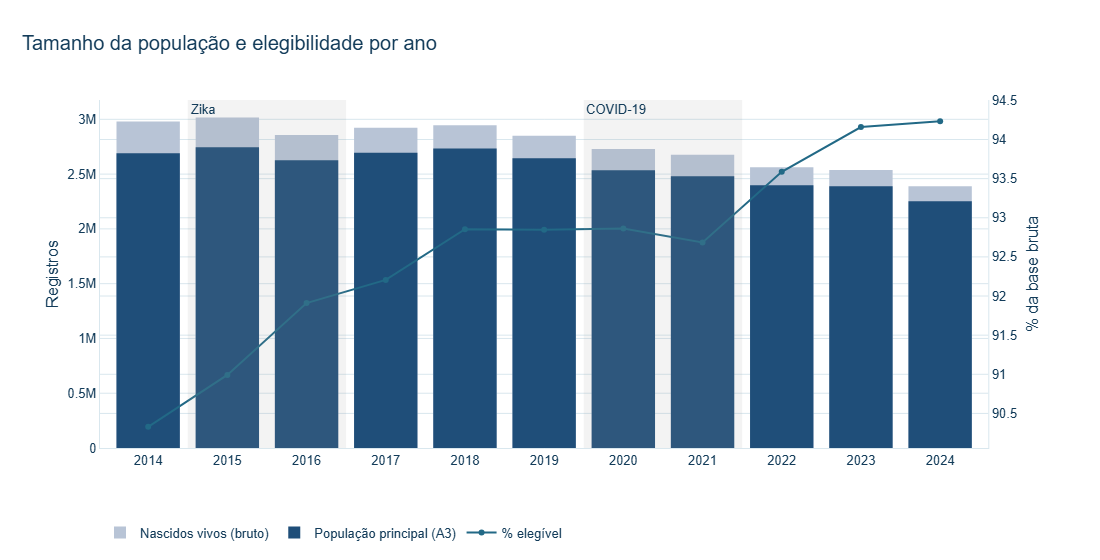

In [8]:
d = descritiva.set_index('ano')
display(d[['n_bruto', 'n_principal', 'pct_principal', 'pct_principal_menos_2024']])
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_bar(x=d.index, y=d.n_bruto, name='Nascidos vivos (bruto)', marker_color='#B8C4D6')
fig.add_bar(x=d.index, y=d.n_principal, name='População principal (A3)', marker_color='#1F4E79')
fig.add_scatter(x=d.index, y=d.pct_principal, name='% elegível', mode='lines+markers', secondary_y=True)
fig.update_layout(barmode='overlay'); fig.update_yaxes(title='Registros', secondary_y=False)
fig.update_yaxes(title='% da base bruta', secondary_y=True)
mostrar(marcar_eventos(fig), 'Tamanho da população e elegibilidade por ano', 'populacao')

O número de nascidos vivos cai 20% entre 2014 e 2024 (queda contínua desde 2018). A fração elegível cresce de 90,3% para 94,2%: a população principal encolhe menos que a base bruta porque o preenchimento de `MESPRENAT` melhorou.

## 6. População elegível

Exclusões de cada etapa, em % da base bruta do ano.

In [9]:
fluxo = pd.DataFrame([r for a in aprovados for r in auditorias[a]['fluxo']])
exclusoes = fluxo.pivot(index='ano', columns='etapa', values='n_excluido')[['A0', 'A1', 'A2']]
exclusoes.columns = ['A0: T desconhecido ou peso inválido', 'A1: peso fora de 500–6.000 g', 'A2: gestação não única']
display((100 * exclusoes.div(d.n_bruto, axis=0)).round(3).rename_axis('% da base bruta'))

,A0: T desconhecido ou peso inválido,A1: peso fora de 500–6.000 g,A2: gestação não única
% da base bruta,,,
2014,7.592,0.101,1.978
2015,6.881,0.111,2.016
2016,5.965,0.126,1.999
2017,5.638,0.126,2.030
2018,4.935,0.121,2.090
2019,4.916,0.133,2.103
2020,4.917,0.132,2.088
2021,5.081,0.129,2.105
2022,4.074,0.143,2.196


Quase todo o ganho de elegibilidade vem da etapa A0 (T desconhecido ou peso inválido), que cai de ~7,6% para ~3,4% da base. As exclusões por peso fora de 500–6.000 g (0,10–0,15%) e por gestação não única (2,0–2,2%) ficam praticamente estáveis. **A seletividade da elegibilidade muda ao longo do tempo:** em 2014 a população principal exclui mais registros com mês desconhecido, e não se sabe se esses registros eram semelhantes aos incluídos.

## 7–8. Desfecho e tratamento

,prevalencia_y_pct,prevalencia_y_pct_menos_2024,prevalencia_t_pct,prevalencia_t_pct_menos_2024
ano,,,,
2014,6.927490,-0.967401,78.554386,-7.698540
2015,6.984660,-0.910231,79.401795,-6.851131
2016,7.040639,-0.854252,80.266840,-5.986086
2017,7.032410,-0.862481,81.015263,-5.237663
2018,7.018244,-0.876647,81.735018,-4.517908
2019,7.193892,-0.700999,82.399789,-3.853137
2020,7.088006,-0.806885,82.476035,-3.776890
2021,7.370347,-0.524544,83.912574,-2.340352
2022,7.846470,-0.048421,84.184064,-2.068862


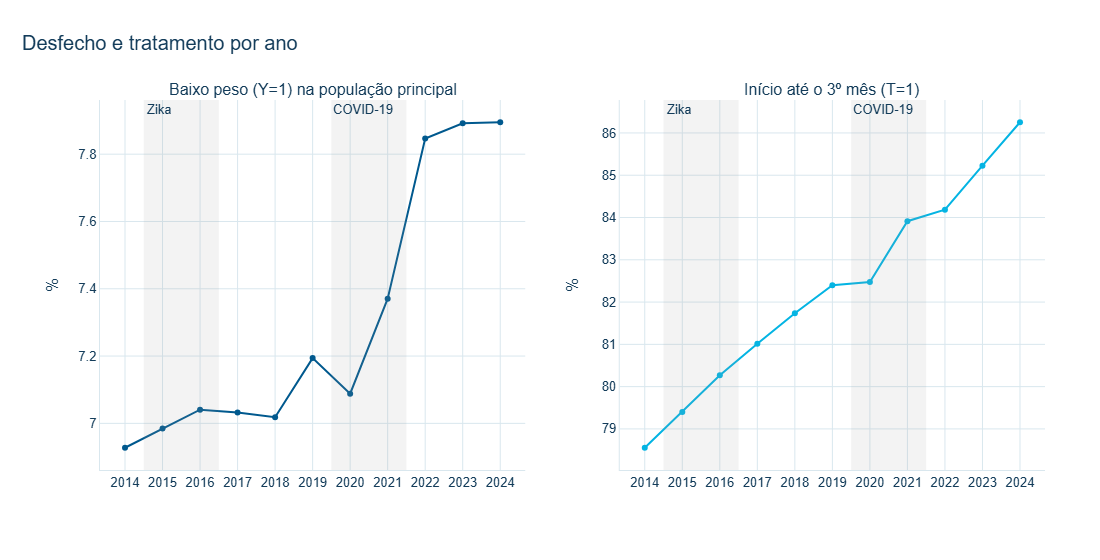

In [10]:
display(d[['prevalencia_y_pct', 'prevalencia_y_pct_menos_2024', 'prevalencia_t_pct', 'prevalencia_t_pct_menos_2024']])
fig = make_subplots(rows=1, cols=2, subplot_titles=['Baixo peso (Y=1) na população principal', 'Início até o 3º mês (T=1)'])
fig.add_scatter(x=d.index, y=d.prevalencia_y_pct, mode='lines+markers', name='Y', row=1, col=1)
fig.add_scatter(x=d.index, y=d.prevalencia_t_pct, mode='lines+markers', name='T', row=1, col=2)
fig.update_yaxes(title='%'); fig.update_layout(showlegend=False)
mostrar(marcar_eventos(fig), 'Desfecho e tratamento por ano', 'prevalencias')

- **Tratamento:** cresce quase linearmente, de 78,6% (2014) para 86,3% (2024), cerca de 0,7 p.p. por ano, com um salto maior em 2021.
- **Desfecho:** baixo peso fica entre 6,9% e 7,2% em 2014–2020, sobe para 7,4% em 2021 e para **7,85% em 2022**, e permanece nesse patamar em 2023–2024 (7,89% e 7,90%). É uma **mudança de nível descritiva** por volta de 2021–2022, não uma oscilação isolada de 2024; fica registrada como **possível mudança temporal a investigar**.

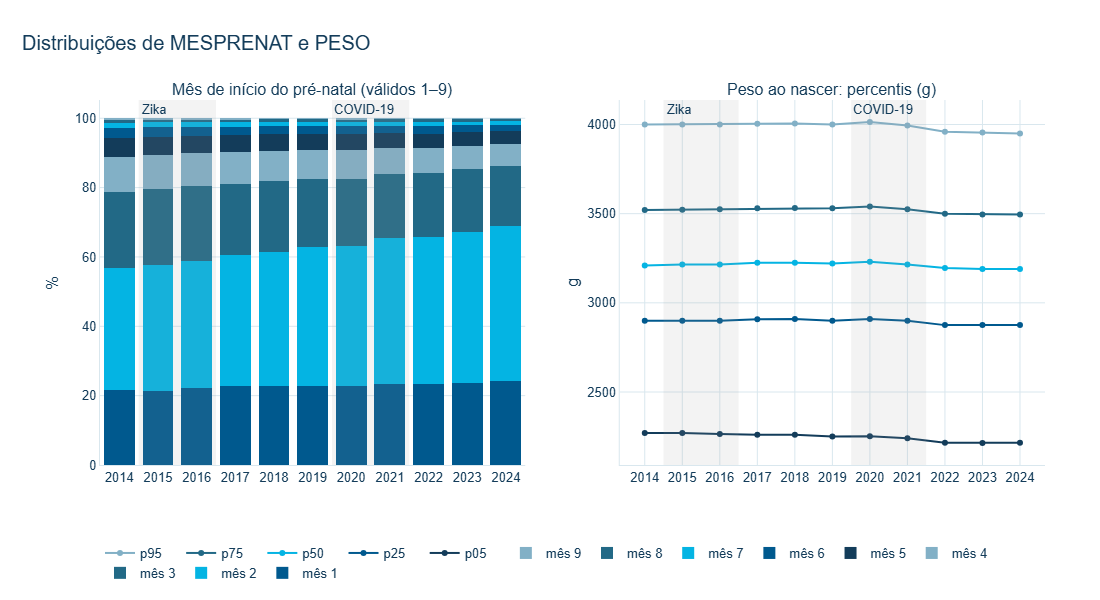

,mesprenat_medio,mes_1_pct,mes_2_pct,mes_3_pct,peso_medio_g,peso_dp_g,peso_p05_g,peso_p50_g,peso_p95_g
ano,,,,,,,,,
2014,2.644,21.504,35.203,21.922,3183.641,554.849,2270.0,3210.0,4000.0
2015,2.616,21.388,36.259,21.825,3184.792,557.215,2270.0,3215.0,4000.0
2016,2.579,22.067,36.885,21.376,3184.244,558.476,2265.0,3215.0,4000.0
2017,2.541,22.895,37.531,20.662,3189.626,562.005,2260.0,3225.0,4004.0
2018,2.515,22.776,38.691,20.335,3190.506,560.936,2260.0,3225.0,4005.0
2019,2.490,22.901,39.828,19.735,3183.933,562.587,2250.0,3220.0,4000.0
2020,2.491,22.725,40.552,19.267,3194.066,565.823,2252.0,3230.0,4014.0
2021,2.438,23.268,42.214,18.493,3178.847,563.500,2240.0,3215.0,3995.0
2022,2.431,23.229,42.635,18.382,3153.009,560.168,2215.0,3195.0,3960.0


In [11]:
meses = d[[f'mes_{k}_pct' for k in range(1, 10)]].rename(columns=lambda c: c.split('_')[1])
fig = make_subplots(rows=1, cols=2, subplot_titles=['Mês de início do pré-natal (válidos 1–9)', 'Peso ao nascer: percentis (g)'])
for mes in meses.columns:
    fig.add_bar(x=meses.index, y=meses[mes], name=f'mês {mes}', row=1, col=1)
for p in ['p05', 'p25', 'p50', 'p75', 'p95']:
    fig.add_scatter(x=d.index, y=d[f'peso_{p}_g'], mode='lines+markers', name=p, row=1, col=2)
fig.update_layout(barmode='stack'); fig.update_yaxes(title='%', row=1, col=1); fig.update_yaxes(title='g', row=1, col=2)
mostrar(marcar_eventos(fig), 'Distribuições de MESPRENAT e PESO', 'mesprenat_peso', altura=600)
display(d[['mesprenat_medio', 'mes_1_pct', 'mes_2_pct', 'mes_3_pct', 'peso_medio_g', 'peso_dp_g', 'peso_p05_g', 'peso_p50_g', 'peso_p95_g']].round(3))

- O mês médio de início do pré-natal cai de 2,64 para 2,35; a participação do 2º mês cresce de 35% para 45%.
- O peso médio fica estável em ~3.184–3.194 g até 2020 e cai para ~3.150 g em 2022–2024 (mediana de 3.215–3.230 g para 3.190 g), coerente com o aumento do baixo peso.

## 9. Ausentes e ignorados

,t_desconhecido_pct,mesprenat_99_pct,mesprenat_vazio_pct,mesprenat_outro_pct,peso_invalido_p0_pct,peso_fora_p1_pct,idade_ausente_principal_pct,codmunres_malformado_bruto,dtnasc_invalida,dtnasc_fora_do_ano
ano,,,,,,,,,,
2014,7.5672,3.6475,3.8321,0.0875,0.0538,0.1758,0.0025,0,0,0
2015,6.8602,2.9988,3.8614,0.0000,0.0391,0.1707,0.0021,0,0,0
2016,5.9478,2.7312,3.2166,0.0000,0.0358,0.1800,0.0019,0,0,0
2017,5.6186,2.5323,3.0863,0.0000,0.0340,0.1758,0.0011,0,0,0
2018,4.9137,2.4135,2.5002,0.0000,0.0321,0.1686,0.0024,0,0,0
2019,4.8958,2.3411,2.5547,0.0000,0.0262,0.1743,0.0017,0,0,0
2020,4.9014,2.4792,2.4222,0.0000,0.0233,0.1711,0.0022,0,0,0
2021,5.0675,2.4046,2.6628,0.0000,0.0210,0.1644,0.0017,0,0,0
2022,4.0638,2.0597,2.0041,0.0000,0.0155,0.1732,0.0014,0,0,0


variavel,CODMUNRES,ESCMAE2010,ESTCIVMAE,IDADEMAE,PARIDADE,QTDFILMORT,RACACORMAE
% ausente/ignorado na população principal,,,,,,,
2014,0.0,1.375,0.966,0.003,0.0,8.371,3.446
2015,0.0,1.268,0.921,0.002,0.0,7.918,3.707
2016,0.0,1.124,0.922,0.002,0.0,7.132,3.812
2017,0.0,1.123,0.920,0.001,0.0,5.846,3.228
2018,0.0,1.099,0.882,0.002,0.0,4.410,2.849
2019,0.0,0.881,0.834,0.002,0.0,3.376,2.408
2020,0.0,0.832,0.899,0.002,0.0,3.315,2.415
2021,0.0,0.867,1.049,0.002,0.0,2.914,2.150
2022,0.0,0.790,0.771,0.001,0.0,2.213,1.848


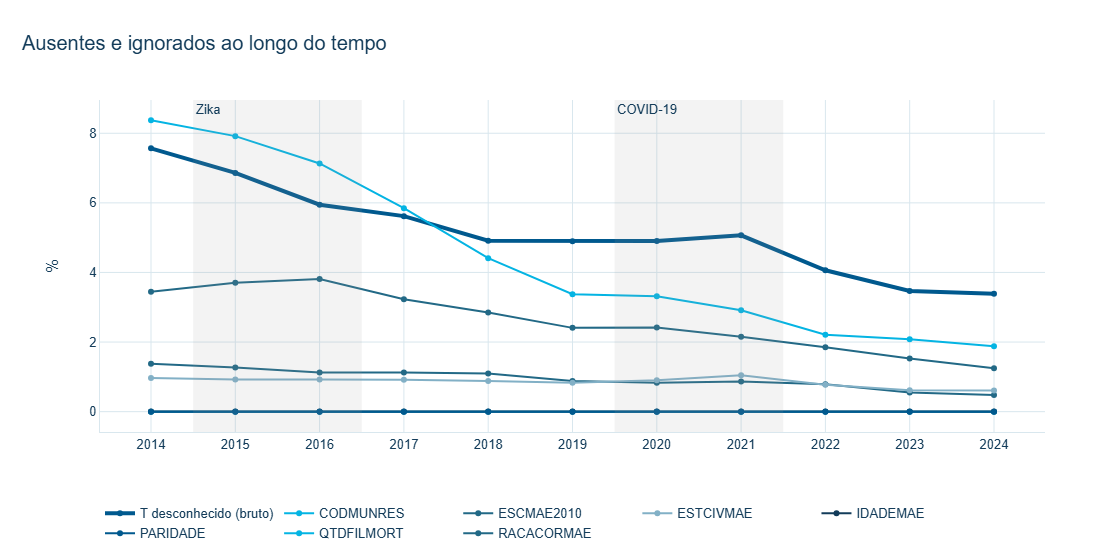

In [12]:
q = qualidade.set_index('ano')
display(q[['t_desconhecido_pct', 'mesprenat_99_pct', 'mesprenat_vazio_pct', 'mesprenat_outro_pct',
           'peso_invalido_p0_pct', 'peso_fora_p1_pct', 'idade_ausente_principal_pct',
           'codmunres_malformado_bruto', 'dtnasc_invalida', 'dtnasc_fora_do_ano']].round(4))
mx = missing.pivot(index='ano', columns='variavel', values='pct_total')
display(mx.round(3).rename_axis('% ausente/ignorado na população principal'))
fig = go.Figure()
fig.add_scatter(x=q.index, y=q.t_desconhecido_pct, mode='lines+markers', name='T desconhecido (bruto)', line=dict(width=4))
for v in mx.columns:
    fig.add_scatter(x=mx.index, y=mx[v], mode='lines+markers', name=v)
fig.update_yaxes(title='%')
mostrar(marcar_eventos(fig), 'Ausentes e ignorados ao longo do tempo', 'ausentes')

A qualidade de preenchimento **melhora sistematicamente**: T desconhecido cai de 7,6% para 3,4%; `RACACORMAE` ignorado de 3,5% para 1,3%; `QTDFILMORT` ignorado de 8,4% para 1,9%; `ESCMAE2010` de 1,4% para 0,5%. `PARIDADE`, `IDADEMAE` e `CODMUNRES` não têm ignorados na população principal em nenhum ano. Consequência: comparações entre anos misturam mudança real com melhora de registro, sobretudo em 2014–2017.

## 10. Composição das covariáveis

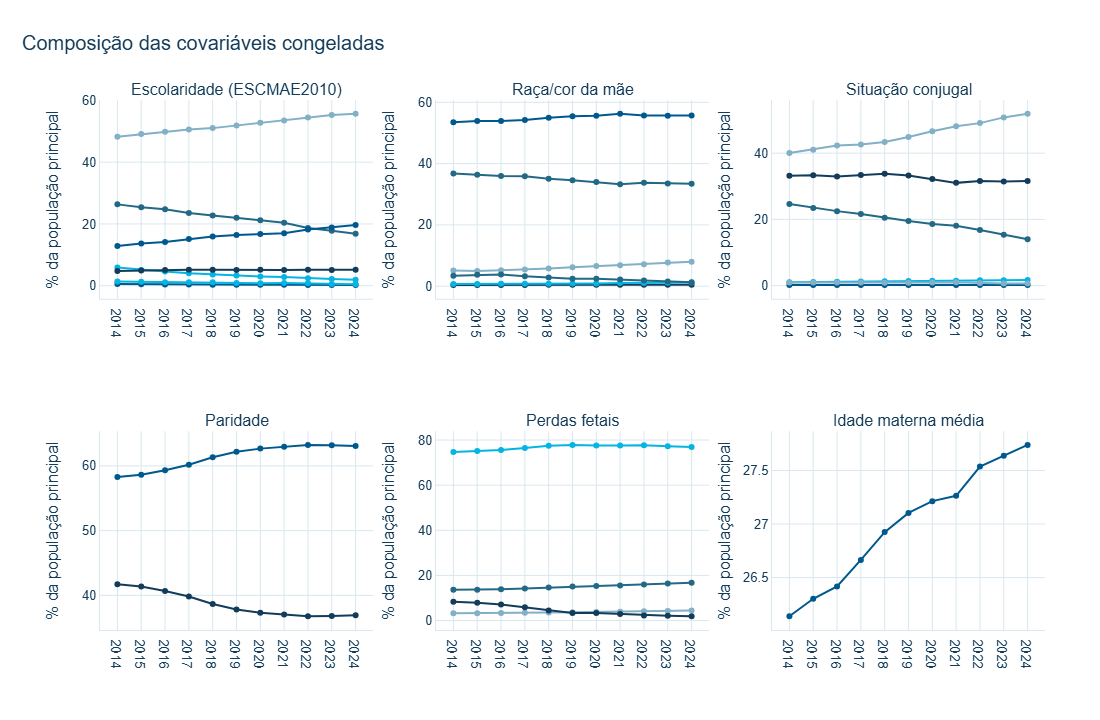

,ano,variavel,categoria,pct,pct_menos_2024
13,2014,SITUACAO_CONJUGAL,1,40.04,-11.88
65,2015,SITUACAO_CONJUGAL,1,41.05,-10.87
17,2014,SITUACAO_CONJUGAL,5,24.62,10.63
117,2016,SITUACAO_CONJUGAL,1,42.28,-9.65
2,2014,ESCOLARIDADE_MAE,2,26.34,9.52
69,2015,SITUACAO_CONJUGAL,5,23.44,9.46
169,2017,SITUACAO_CONJUGAL,1,42.65,-9.27
54,2015,ESCOLARIDADE_MAE,2,25.40,8.57
221,2018,SITUACAO_CONJUGAL,1,43.37,-8.55
121,2016,SITUACAO_CONJUGAL,5,22.49,8.51


In [13]:
rotulos = {'ESCOLARIDADE_MAE': 'Escolaridade (ESCMAE2010)', 'RACA_COR_MAE': 'Raça/cor da mãe',
           'SITUACAO_CONJUGAL': 'Situação conjugal', 'PARIDADE_CAT': 'Paridade', 'PERDAS_FETAIS_CAT': 'Perdas fetais'}
fig = make_subplots(rows=2, cols=3, subplot_titles=list(rotulos.values()) + ['Idade materna média'])
for i, (var, nome) in enumerate(rotulos.items()):
    sub = covariaveis[covariaveis.variavel == var].pivot(index='ano', columns='categoria', values='pct')
    for cat in sub.columns:
        fig.add_scatter(x=sub.index, y=sub[cat], mode='lines+markers', name=f'{var}={cat}', showlegend=False,
                        row=i // 3 + 1, col=i % 3 + 1)
fig.add_scatter(x=d.index, y=d.idade_media, mode='lines+markers', showlegend=False, row=2, col=3)
fig.update_yaxes(title='% da população principal')
mostrar(fig, 'Composição das covariáveis congeladas', 'covariaveis', altura=720)
maiores = (covariaveis[(covariaveis.variavel != 'UF_RESIDENCIA') & (covariaveis.ano != 2024)]
           .assign(abs_dif=lambda t: t.pct_menos_2024.abs()).sort_values('abs_dif', ascending=False)
           .head(12)[['ano', 'variavel', 'categoria', 'pct', 'pct_menos_2024']])
display(maiores.round(2))

A composição muda de forma gradual e monotônica:

- escolaridade 5 (superior) cresce de 12,8% para 19,7%; a categoria 2 cai de 26,3% para 16,8%;
- situação conjugal 1 cresce de 40% para 52%, e a 5 cai de 25% para 14%;
- raça/cor 2 cresce de 5,1% para 7,9%; a categoria 1 cai de 36,8% para 33,4%;
- multíparas passam de 58% para 63% (estável desde 2021); idade média de 26,1 para 27,7 anos.

Nenhuma dessas mudanças é abrupta; 2024 continua tendências da década. Para o notebook 08, isso significa que o SMD **entre anos** pode ser relevante mesmo quando o SMD entre T=1 e T=0 dentro de cada ano é parecido.

## 11. Distribuição geográfica

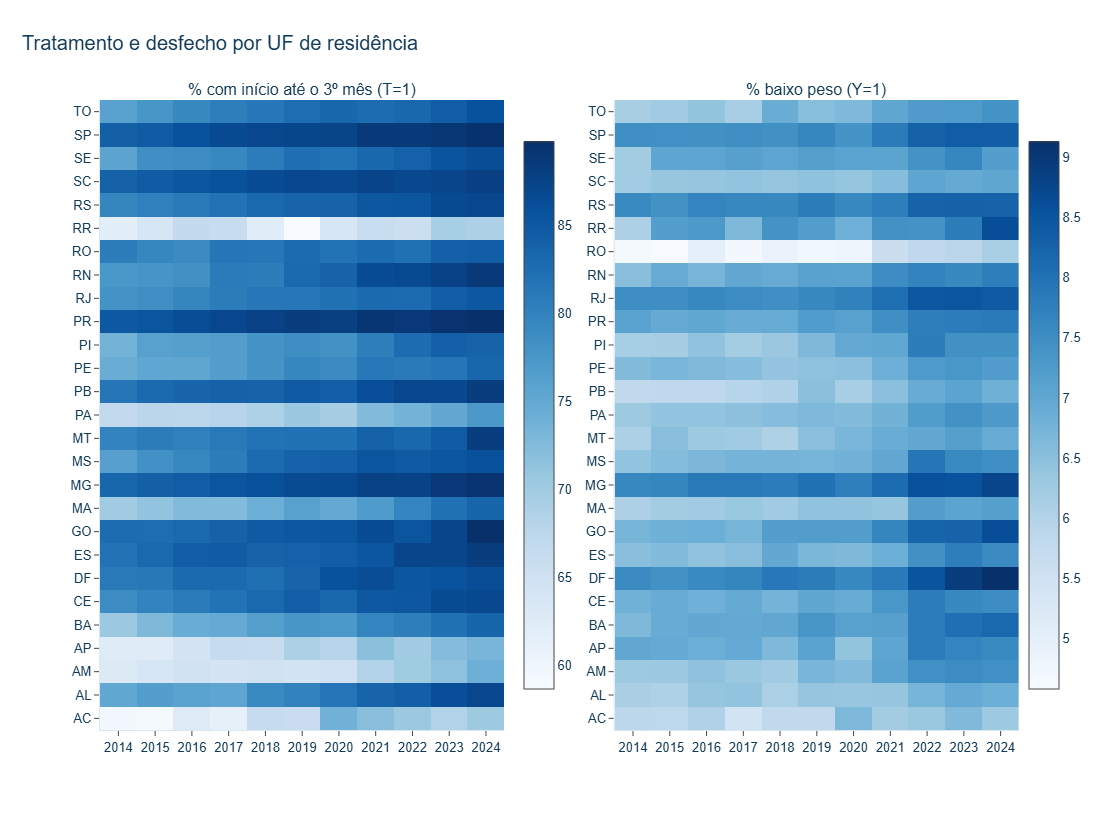

,pct_t1_min,pct_t1_max,dif_t1_max_vs_2024
sigla,,,
MA,70.07,83.48,13.41
BA,70.51,83.48,12.97
AL,75.24,87.10,11.86
RN,77.36,88.69,11.33
AC,59.19,73.61,11.21
AM,62.90,74.05,11.15
AP,62.42,73.22,10.79
SE,75.68,86.34,10.66


,ano,n_bruto,n_principal


In [14]:
g = geografia[geografia.uf != 'IGNORADO'].assign(sigla=lambda t: t.uf.map(UF))
fig = make_subplots(rows=1, cols=2, subplot_titles=['% com início até o 3º mês (T=1)', '% baixo peso (Y=1)'],
                    horizontal_spacing=0.12)
for j, col in enumerate(['pct_t1', 'prevalencia_y'], 1):
    m = g.pivot(index='sigla', columns='ano', values=col)
    fig.add_heatmap(z=m.values, x=m.columns, y=m.index, colorscale='Blues', showscale=True,
                    colorbar=dict(x=0.45 if j == 1 else 1.0, len=0.9), row=1, col=j)
mostrar(fig, 'Tratamento e desfecho por UF de residência', 'geografia', altura=820)
amplitude = g.groupby('sigla').agg(pct_t1_min=('pct_t1', 'min'), pct_t1_max=('pct_t1', 'max'),
                                   dif_t1_max_vs_2024=('pct_t1_menos_2024', lambda s: s.abs().max()))
display(amplitude.sort_values('dif_t1_max_vs_2024', ascending=False).head(8).round(2))
display(geografia[geografia.uf == 'IGNORADO'][['ano', 'n_bruto', 'n_principal']])

Todas as UFs aumentam a proporção de T=1, mas os níveis continuam muito diferentes: Norte (AC, AM, RR, AP, PA) começa em 59–67% e termina em 69–77%; Sul e Sudeste vão de 78–85% em 2014 para 85–90% em 2024. Não há registros com UF de residência ignorada. O aumento do baixo peso a partir de 2022 aparece na maioria das UFs, não apenas em uma região. UFs pequenas (RR, AC, AP) oscilam mais de ano para ano; a oscilação de RR em 2024 (8,6% de baixo peso) deve ser lida com cautela.

## 12. Associação bruta T–Y ao longo do tempo

Diferença de risco **sem ajuste**, apenas descritiva, como no notebook 02 para 2024. Não é efeito causal e não substitui o AIPW; serve para ver se o sinal bruto observado em 2024 aparece nos outros anos.

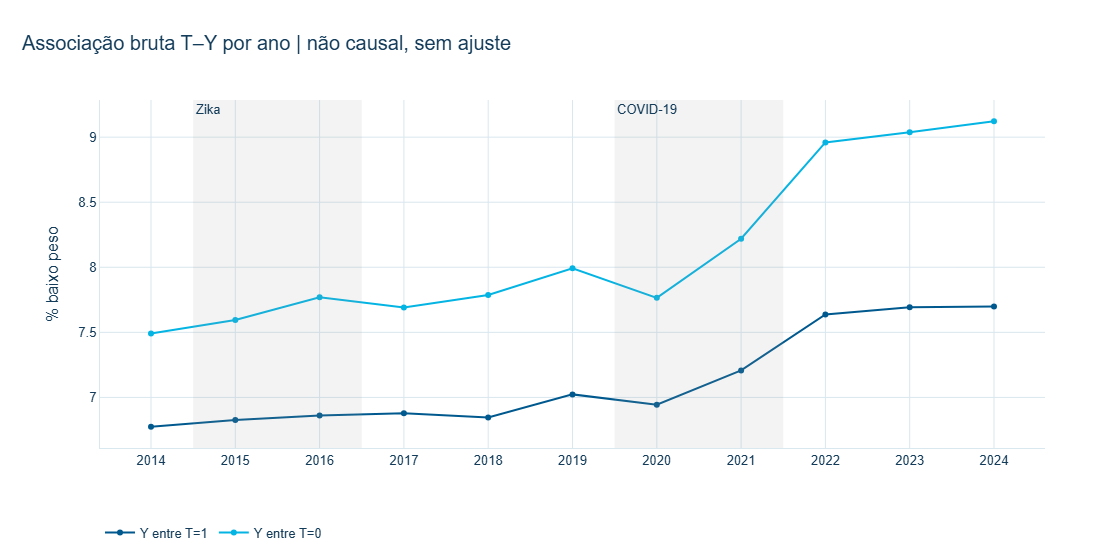

,risco_y_t1_pct,risco_y_t0_pct,diferenca_bruta_pp_nao_causal,diferenca_bruta_pp_nao_causal_menos_2024
ano,,,,
2014,6.7738,7.4906,-0.7168,0.7071
2015,6.8262,7.5955,-0.7694,0.6545
2016,6.8613,7.7703,-0.9090,0.5149
2017,6.8780,7.6912,-0.8132,0.6107
2018,6.8465,7.7867,-0.9402,0.4836
2019,7.0232,7.9930,-0.9698,0.4540
2020,6.9441,7.7653,-0.8211,0.6027
2021,7.2076,8.2193,-1.0117,0.4122
2022,7.6373,8.9598,-1.3224,0.1014


In [15]:
fig = go.Figure()
fig.add_scatter(x=d.index, y=d.risco_y_t1_pct, mode='lines+markers', name='Y entre T=1')
fig.add_scatter(x=d.index, y=d.risco_y_t0_pct, mode='lines+markers', name='Y entre T=0')
fig.update_yaxes(title='% baixo peso')
mostrar(marcar_eventos(fig), 'Associação bruta T–Y por ano | não causal, sem ajuste', 'associacao_bruta')
display(d[['risco_y_t1_pct', 'risco_y_t0_pct', 'diferenca_bruta_pp_nao_causal', 'diferenca_bruta_pp_nao_causal_menos_2024']].round(4))

A diferença bruta de risco (T=1 menos T=0) é **negativa em todos os anos**, mas sua magnitude **aumenta**: −0,72 p.p. em 2014, −0,77 a −1,01 p.p. em 2015–2021 e −1,32 a −1,42 p.p. em 2022–2024. O risco entre T=0 sobe mais (7,5% → 9,1%) que entre T=1 (6,8% → 7,7%). Isso é associação sem ajuste; a mudança pode refletir composição, seleção do grupo que começa tarde (cada vez menor) ou registro. **2024 tem a maior diferença bruta da série.**

## 13. Contextos temporais

As faixas cinzas marcam **Zika (2015–2016)** e **COVID-19 (2020–2021)**. São marcadores de leitura: mudanças nesses anos são descritas, não atribuídas a esses eventos, porque este notebook não tem desenho para isso.

Descrição das mudanças observadas nas faixas marcadas, sem atribuição causal:

- **2015–2016 (Zika):** a série de nascidos vivos tem sua primeira queda (3,02 → 2,86 milhões) e a diferença bruta fica mais negativa em 2016 (−0,91 p.p.); a tendência de T e das covariáveis segue sem mudança visível.
- **2020–2021 (COVID-19):** T quase não cresce em 2020 e salta em 2021; o baixo peso sobe em 2021 e apresenta mudança de nível descritiva em 2022, **depois** da faixa; a diferença bruta cai para −0,82 p.p. em 2020 e volta a −1,01 p.p. em 2021.

Sem um desenho para eventos, essas coincidências não identificam causa.

## 14. 2024 frente aos anos anteriores

Para cada métrica central: faixa de 2014–2023, valor de 2024 e o desvio de 2024 em relação a uma **tendência linear** ajustada em 2014–2023 (em unidades do desvio-padrão dos resíduos). É um resumo descritivo com 10 pontos; não é teste de hipótese.

In [16]:
resumo = []
for janela, inicio in (('principal 2014–2023', 2014), ('sensibilidade 2018–2023', 2018)):
    historico = d.loc[(d.index >= inicio) & (d.index < 2024)]
    for col in ['pct_principal', 'prevalencia_y_pct', 'prevalencia_t_pct', 'diferenca_bruta_pp_nao_causal',
                'peso_medio_g', 'mesprenat_medio', 'idade_media']:
        inclinacao, intercepto = np.polyfit(historico.index, historico[col], 1)
        projetado = inclinacao * 2024 + intercepto
        residuos = historico[col] - (inclinacao * historico.index + intercepto)
        resumo.append({'historico': janela, 'metrica': col, 'min': historico[col].min(), 'max': historico[col].max(),
                       'valor_2024': d.loc[2024, col],
                       'dentro_da_faixa': historico[col].min() <= d.loc[2024, col] <= historico[col].max(),
                       'tendencia_por_ano': inclinacao, 'projecao_linear_2024': projetado,
                       'desvio_2024_da_projecao': d.loc[2024, col] - projetado,
                       'desvio_em_dp_residual': (d.loc[2024, col] - projetado) / residuos.std(ddof=2)})
comparacao_2024 = pd.DataFrame(resumo)
display(comparacao_2024.round(4))

,historico,metrica,min,max,valor_2024,dentro_da_faixa,tendencia_por_ano,projecao_linear_2024,desvio_2024_da_projecao,desvio_em_dp_residual
0,principal 2014–2023,pct_principal,90.3285,94.1586,94.2346,False,0.3544,94.3925,-0.1579,-0.3810
1,principal 2014–2023,prevalencia_y_pct,6.9275,7.8916,7.8949,False,0.1012,7.7961,0.0988,0.5242
2,principal 2014–2023,prevalencia_t_pct,78.5544,85.2251,86.2529,False,0.7078,85.8100,0.4429,1.8042
3,principal 2014–2023,diferenca_bruta_pp_nao_causal,-1.3457,-0.7168,-1.4239,False,-0.0612,-1.2986,-0.1253,-1.0536
4,principal 2014–2023,peso_medio_g,3151.1065,3194.0664,3150.2727,False,-3.2456,3161.5263,-11.2535,-0.9336
5,principal 2014–2023,mesprenat_medio,2.3921,2.6438,2.3480,False,-0.0269,2.3655,-0.0175,-1.5011
6,principal 2014–2023,idade_media,26.1382,27.6383,27.7390,False,0.1709,27.8605,-0.1214,-1.8227
7,sensibilidade 2018–2023,pct_principal,92.6848,94.1586,94.2346,False,0.2447,94.0223,0.2123,0.5322
8,sensibilidade 2018–2023,prevalencia_y_pct,7.0182,7.8916,7.8949,False,0.1888,8.0621,-0.1672,-1.0379
9,sensibilidade 2018–2023,prevalencia_t_pct,81.7350,85.2251,86.2529,False,0.6926,85.7461,0.5068,1.5937


2024 fica **fora da faixa de 2014–2023 em todas as métricas centrais**, mas sempre na direção das tendências, e a distância em relação à tendência linear é pequena (entre −1,8 e +1,8 desvios-padrão dos resíduos). Ou seja, 2024 é o **extremo de uma série com tendência**, não um ponto atípico. As exceções à linearidade estão por volta de 2021–2022, não em 2024: o baixo peso e o peso médio apresentam ali uma mudança de nível descritiva que se mantém. Com o histórico da sensibilidade (2018–2023), a leitura é a mesma: 2024 segue a direção dos anos recentes.

## 15. Síntese sobre estabilidade temporal

**Os padrões de 2024 persistem?**

- **Sim, na direção:** em todos os anos, a maioria das gestantes começa o pré-natal até o 3º mês e o risco bruto de baixo peso é menor entre elas.
- **Não na magnitude:** a proporção tratada sobe 7,7 p.p., o baixo peso apresenta mudança de nível descritiva por volta de 2021–2022 e a diferença bruta dobra entre 2014 e 2024.

**2024 é típico ou particular?** 2024 está no **extremo recente das tendências observadas** e é **semelhante em direção a 2022–2023**; não mostra uma mudança própria. A mudança descritiva mais marcante ocorre por volta de **2021–2022** (desfecho, peso médio e diferença bruta) e é uma **possível mudança temporal a investigar**, não uma quebra estrutural demonstrada nem efeito atribuível a COVID-19 ou Zika.

**Mais anos, mais validade causal?** Não. Esta descritiva aumenta a **evidência sobre estabilidade temporal**; não resolve confundimento, seleção por elegibilidade ou mudanças de registro. Como a composição muda ano a ano, estimativas por ano (notebook 09) podem diferir por causa da população, e não só do efeito.

## 16. Decisão para o notebook 08

**Decisão metodológica (revisão humana de 30/09/2026): H1 aprovada.**

| Janela | Anos | Contrato | Papel |
|---|---|---|---|
| **Principal** | 2014–2024 (11 anos) | v1.1 = v1 + H1 | análise principal dos notebooks 08 e 09 |
| **Sensibilidade** | 2018–2024 (7 anos) | v1 estrito, sem H1 | **obrigatória** nos notebooks 08 e 09 |

As duas janelas foram congeladas antes de qualquer estimação multianual e **as duas serão sempre reportadas**; a escolha entre elas não pode depender de resultados futuros.

Plano do notebook 08 (camada B, comparabilidade e suporte), em cada ano: SMD entre T=1 e T=0; composição frente a 2024; distribuição de T; suporte das covariáveis; escore de propensão com a mesma especificação de 2024, **ajustado separadamente em cada ano**; suporte comum, positividade, fração fora de suporte e perfis problemáticos. Os diagnósticos principais serão repetidos na sensibilidade 2018–2024. A mudança descritiva de 2021–2022 será tratada como **hipótese de mudança temporal**, sem AIPW, CATE ou empilhamento.

## 17. Limitações

- **Descritivo, não causal.** Nenhuma diferença entre anos aqui é explicada causalmente; tendências podem refletir composição, registro ou cobertura.
- **Regras de 2024 aplicadas retroativamente.** A comparabilidade é de definição, não garante que o preenchimento de `MESPRENAT` ou `ESCMAE2010` tenha a mesma qualidade em todos os anos e UFs.
- **Versões dos arquivos.** Os resultados valem para os arquivos com os SHA-256 registrados; o Ministério republica bases (2016–2024 em 08/05/2026).
- **Dicionário oficial até 2019**; o código 99 de `MESPRENAT` continua sem documentação no layout estrutural.
- **Sem ligação entre anos:** mães com mais de um nascimento no período aparecem como registros independentes.
- **Contextos (Zika, COVID-19)** são marcadores, não variáveis do desenho.
- 2010–2013, 2025 e 2026 continuam fora da janela principal por decisão do notebook 06.